# **TASK 05 - MODEL TRAINING AND OPTIMIZATION**

## **Imports & Environment Setup**

In [19]:
import copy
import json
import os
import pickle
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch_geometric.data import Data
from torch_geometric.utils import to_undirected

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

os.makedirs("models_checkpoints", exist_ok=True)
os.makedirs("reports", exist_ok=True)

print("Device available:", "GPU" if torch.cuda.is_available() else "CPU")


Device available: GPU


## **Load Processed OGBN-Arxiv Data**

In [20]:
DATA_PATH = "data/processed/processed_data.pkl"

with open(DATA_PATH, "rb") as file:
    processed_data = pickle.load(file)

print("Available data keys:")
print(processed_data.keys())

Available data keys:
dict_keys(['features', 'labels', 'edge_index', 'train_idx', 'valid_idx', 'test_idx'])


## **Graph Data Preparation**

In [21]:
features = processed_data["features"]
labels = processed_data["labels"].view(-1)

# OGBN-Arxiv citation links are directed. Adding reverse links allows
# both models to aggregate information in both citation directions.
edge_index = to_undirected(
    processed_data["edge_index"].long(),
    num_nodes=features.shape[0]
)

train_idx = processed_data["train_idx"].view(-1)
valid_idx = processed_data["valid_idx"].view(-1)
test_idx = processed_data["test_idx"].view(-1)

num_nodes = features.shape[0]
num_features = features.shape[1]
num_classes = int(labels.max().item()) + 1

print(f"Number of nodes: {num_nodes:,}")
print(f"Directed edges before conversion: {processed_data['edge_index'].shape[1]:,}")
print(f"Edges after bidirectional conversion: {edge_index.shape[1]:,}")
print(f"Number of features: {num_features}")
print(f"Number of classes: {num_classes}")
print(f"Training nodes: {len(train_idx):,}")
print(f"Validation nodes: {len(valid_idx):,}")
print(f"Test nodes: {len(test_idx):,}")

Number of nodes: 169,343
Directed edges before conversion: 1,166,243
Edges after bidirectional conversion: 2,315,598
Number of features: 128
Number of classes: 40
Training nodes: 90,941
Validation nodes: 29,799
Test nodes: 48,603


## **Reproducibility & Device Setup**

In [22]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

graph_data = Data(
    x=features.float(),
    edge_index=edge_index.long(),
    y=labels.long()
).to(DEVICE)

train_idx = train_idx.long().to(DEVICE)
valid_idx = valid_idx.long().to(DEVICE)
test_idx = test_idx.long().to(DEVICE)

print("Using device:", DEVICE)
print("Graph device:", graph_data.x.device)
print("Graph data prepared successfully.")


Using device: cuda
Graph device: cuda:0
Graph data prepared successfully.


## **Load Task 4 Model Configuration**

The saved Task 4 configuration provides the architecture parameters for the two required models, GCN and GraphSAGE, and the bonus GAT model.

In [30]:
CONFIG_PATH = "models_checkpoints/model_config.json"

if os.path.exists(CONFIG_PATH):
    with open(CONFIG_PATH, "r") as file:
        model_config = json.load(file)
    print(f"Loaded Task 4 configuration from {CONFIG_PATH}")
else:
    # Fallback matches the latest Task 4 model configuration.
    model_config = {
        "gcn": {
            "class": "GCN",
            "in_channels": num_features,
            "hidden_channels": 256,
            "out_channels": num_classes,
            "dropout": 0.5
        },
        "graphsage": {
            "class": "GraphSAGE",
            "in_channels": num_features,
            "hidden_channels": 256,
            "out_channels": num_classes,
            "dropout": 0.5
        },
        "gat": {
            "class": "GAT",
            "in_channels": num_features,
            "hidden_channels": 256,
            "out_channels": num_classes,
            "dropout": 0.5,
            "heads": 4
        },
        "seed": SEED
    }
    print("model_config.json was not found; using the matching Task 4 configuration.")

for model_name in ["gcn", "graphsage", "gat"]:
    print(f"\n{model_name.upper()} configuration:")
    print(model_config[model_name])

print("\nRandom seed:", model_config["seed"])

gcn_config = model_config["gcn"]
sage_config = model_config["graphsage"]
gat_config = model_config["gat"]


Loaded Task 4 configuration from models_checkpoints/model_config.json

GCN configuration:
{'class': 'GCN', 'hidden_channels': 256, 'dropout': 0.5, 'in_channels': 128, 'out_channels': 40}

GRAPHSAGE configuration:
{'class': 'GraphSAGE', 'hidden_channels': 256, 'dropout': 0.5, 'in_channels': 128, 'out_channels': 40}

GAT configuration:
{'class': 'GAT', 'hidden_channels': 256, 'dropout': 0.5, 'in_channels': 128, 'out_channels': 40, 'heads': 4}

Random seed: 42


## **Model Architectures from Task 4**

The latest shared Task 4 module is used as the single source of truth. GCN and GraphSAGE are the two required architectures. GAT is included as a third, bonus advanced architecture and uses learned multi-head attention weights. Importing the classes avoids architecture drift between Task 4, training, evaluation, and explainability.

In [31]:
from src.models.gnn_models import GCN, GraphSAGE, GAT

print("Latest Task 4 GCN, GraphSAGE, and GAT architectures imported successfully.")


Latest Task 4 GCN, GraphSAGE, and GAT architectures imported successfully.


## **Loss Function, Optimizer & Hyperparameter Search**

In [32]:
LOSS_FUNCTION = nn.CrossEntropyLoss()

HYPERPARAMETER_CONFIGS = [
    {
        "name": "Config 1",
        "learning_rate": 0.01,
        "hidden_channels": 256,
        "dropout": 0.5,
        "weight_decay": 0.0
    },
    {
        "name": "Config 2",
        "learning_rate": 0.005,
        "hidden_channels": 256,
        "dropout": 0.5,
        "weight_decay": 5e-4
    },
    {
        "name": "Config 3",
        "learning_rate": 0.01,
        "hidden_channels": 256,
        "dropout": 0.3,
        "weight_decay": 1e-4
    }
]

GAT_HYPERPARAMETER_CONFIGS = [
    {
        "name": "GAT Config 1",
        "learning_rate": 0.005,
        "hidden_channels": 64,
        "dropout": 0.6,
        "weight_decay": 5e-4,
        "heads": 4
    },
    {
        "name": "GAT Config 2",
        "learning_rate": 0.005,
        "hidden_channels": 128,
        "dropout": 0.5,
        "weight_decay": 5e-4,
        "heads": 2
    },
    {
        "name": "GAT Config 3",
        "learning_rate": 0.01,
        "hidden_channels": 64,
        "dropout": 0.5,
        "weight_decay": 1e-4,
        "heads": 4
    }
]

TUNING_EPOCHS = 100
FINAL_EPOCHS = 500
TUNING_PATIENCE = 25
FINAL_PATIENCE = 75

print("GCN and GraphSAGE search space:")
display(pd.DataFrame(HYPERPARAMETER_CONFIGS))
print("GAT memory-aware search space:")
display(pd.DataFrame(GAT_HYPERPARAMETER_CONFIGS))


GCN and GraphSAGE search space:


,name,learning_rate,hidden_channels,dropout,weight_decay
0,Config 1,0.010,256,0.5,0.0000
1,Config 2,0.005,256,0.5,0.0005
2,Config 3,0.010,256,0.3,0.0001


GAT memory-aware search space:


,name,learning_rate,hidden_channels,dropout,weight_decay,heads
0,GAT Config 1,0.005,64,0.6,0.0005,4
1,GAT Config 2,0.005,128,0.5,0.0005,2
2,GAT Config 3,0.010,64,0.5,0.0001,4


## **Training & Validation Utilities**

In [33]:
def calculate_accuracy(logits, labels):
    predictions = logits.argmax(dim=1)
    return (predictions == labels).float().mean().item()


def train_one_epoch(model, optimizer):
    model.train()
    optimizer.zero_grad()

    logits = model(graph_data.x, graph_data.edge_index)

    loss = LOSS_FUNCTION(
        logits[train_idx],
        graph_data.y[train_idx]
    )

    loss.backward()
    optimizer.step()

    train_accuracy = calculate_accuracy(
        logits[train_idx],
        graph_data.y[train_idx]
    )

    return loss.item(), train_accuracy


@torch.no_grad()
def validate_model(model, split_idx):
    model.eval()

    logits = model(graph_data.x, graph_data.edge_index)

    loss = LOSS_FUNCTION(
        logits[split_idx],
        graph_data.y[split_idx]
    )

    accuracy = calculate_accuracy(
        logits[split_idx],
        graph_data.y[split_idx]
    )

    return loss.item(), accuracy


print("Training and validation functions created successfully.")

Training and validation functions created successfully.


In [34]:
def train_model(
    model,
    learning_rate,
    weight_decay,
    epochs,
    patience,
    print_every=10
):
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=10,
        min_lr=1e-5
    )

    training_log = []
    best_state = copy.deepcopy(model.state_dict())
    best_validation_accuracy = -1.0
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = train_one_epoch(model, optimizer)
        val_loss, val_accuracy = validate_model(model, valid_idx)
        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]
        training_log.append({
            "epoch": epoch,
            "learning_rate": current_lr,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "validation_loss": val_loss,
            "validation_accuracy": val_accuracy
        })

        if val_accuracy > best_validation_accuracy:
            best_validation_accuracy = val_accuracy
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch == 1 or epoch % print_every == 0:
            print(
                f"Epoch {epoch:03d} | LR: {current_lr:.6f} | "
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f} | "
                f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f}"
            )

        if epochs_without_improvement >= patience:
            print(
                f"Early stopping at epoch {epoch}. "
                f"Restoring epoch {best_epoch} with validation accuracy "
                f"{best_validation_accuracy:.4f}."
            )
            break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(training_log)


print("Training function with scheduling, early stopping, and best-weight restoration created.")


Training function with scheduling, early stopping, and best-weight restoration created.


## **Hyperparameter Tuning**

### **GCN Tuning Results**

In [36]:
gcn_tuning_results = []

for config in HYPERPARAMETER_CONFIGS:
    print(f"\nTraining GCN - {config['name']}")
    set_seed(SEED)

    trial_model = GCN(
        in_channels=gcn_config["in_channels"],
        hidden_channels=config["hidden_channels"],
        out_channels=gcn_config["out_channels"],
        dropout=config["dropout"]
    ).to(DEVICE)

    trained_model, log = train_model(
        model=trial_model,
        learning_rate=config["learning_rate"],
        weight_decay=config["weight_decay"],
        epochs=TUNING_EPOCHS,
        patience=TUNING_PATIENCE
    )

    best_row = log.loc[log["validation_accuracy"].idxmax()]
    gcn_tuning_results.append({
        "configuration": config["name"],
        "learning_rate": config["learning_rate"],
        "hidden_channels": config["hidden_channels"],
        "dropout": config["dropout"],
        "weight_decay": config["weight_decay"],
        "best_epoch": int(best_row["epoch"]),
        "best_validation_loss": best_row["validation_loss"],
        "best_validation_accuracy": best_row["validation_accuracy"]
    })

    del trial_model, trained_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

gcn_tuning_results = pd.DataFrame(gcn_tuning_results).sort_values(
    "best_validation_accuracy", ascending=False
).reset_index(drop=True)

gcn_tuning_results



Training GCN - Config 1
Epoch 001 | LR: 0.010000 | Train Loss: 4.2089 | Train Acc: 0.0257 | Val Loss: 2.8515 | Val Acc: 0.4012
Epoch 010 | LR: 0.010000 | Train Loss: 1.3440 | Train Acc: 0.6457 | Val Loss: 1.2594 | Val Acc: 0.6530
Epoch 020 | LR: 0.010000 | Train Loss: 1.1663 | Train Acc: 0.6763 | Val Loss: 1.0886 | Val Acc: 0.6872
Epoch 030 | LR: 0.010000 | Train Loss: 1.0896 | Train Acc: 0.6894 | Val Loss: 1.0140 | Val Acc: 0.7027
Epoch 040 | LR: 0.010000 | Train Loss: 1.0476 | Train Acc: 0.6986 | Val Loss: 0.9885 | Val Acc: 0.7091
Epoch 050 | LR: 0.010000 | Train Loss: 1.0139 | Train Acc: 0.7058 | Val Loss: 0.9713 | Val Acc: 0.7111
Epoch 060 | LR: 0.010000 | Train Loss: 0.9885 | Train Acc: 0.7106 | Val Loss: 0.9591 | Val Acc: 0.7141
Epoch 070 | LR: 0.010000 | Train Loss: 0.9676 | Train Acc: 0.7144 | Val Loss: 0.9473 | Val Acc: 0.7171
Epoch 080 | LR: 0.010000 | Train Loss: 0.9480 | Train Acc: 0.7184 | Val Loss: 0.9374 | Val Acc: 0.7179
Epoch 090 | LR: 0.010000 | Train Loss: 0.9321 | 

,configuration,learning_rate,hidden_channels,dropout,weight_decay,best_epoch,best_validation_loss,best_validation_accuracy
0,Config 3,0.010,256,0.3,0.0001,96,0.927136,0.722273
1,Config 1,0.010,256,0.5,0.0000,100,0.921610,0.721366
2,Config 2,0.005,256,0.5,0.0005,100,0.997731,0.720225


In [37]:
best_gcn_name = gcn_tuning_results.iloc[0]["configuration"]
best_gcn_config = next(
    config for config in HYPERPARAMETER_CONFIGS
    if config["name"] == best_gcn_name
)

print("Best GCN configuration selected from validation results:")
print(best_gcn_config)


Best GCN configuration selected from validation results:
{'name': 'Config 3', 'learning_rate': 0.01, 'hidden_channels': 256, 'dropout': 0.3, 'weight_decay': 0.0001}


### **GraphSAGE Tuning Results**

In [38]:
sage_tuning_results = []

for config in HYPERPARAMETER_CONFIGS:
    print(f"\nTraining GraphSAGE - {config['name']}")
    set_seed(SEED)

    trial_model = GraphSAGE(
        in_channels=sage_config["in_channels"],
        hidden_channels=config["hidden_channels"],
        out_channels=sage_config["out_channels"],
        dropout=config["dropout"]
    ).to(DEVICE)

    trained_model, log = train_model(
        model=trial_model,
        learning_rate=config["learning_rate"],
        weight_decay=config["weight_decay"],
        epochs=TUNING_EPOCHS,
        patience=TUNING_PATIENCE
    )

    best_row = log.loc[log["validation_accuracy"].idxmax()]
    sage_tuning_results.append({
        "configuration": config["name"],
        "learning_rate": config["learning_rate"],
        "hidden_channels": config["hidden_channels"],
        "dropout": config["dropout"],
        "weight_decay": config["weight_decay"],
        "best_epoch": int(best_row["epoch"]),
        "best_validation_loss": best_row["validation_loss"],
        "best_validation_accuracy": best_row["validation_accuracy"]
    })

    del trial_model, trained_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

sage_tuning_results = pd.DataFrame(sage_tuning_results).sort_values(
    "best_validation_accuracy", ascending=False
).reset_index(drop=True)

sage_tuning_results



Training GraphSAGE - Config 1
Epoch 001 | LR: 0.010000 | Train Loss: 3.8070 | Train Acc: 0.0306 | Val Loss: 2.3273 | Val Acc: 0.4580
Epoch 010 | LR: 0.010000 | Train Loss: 1.4640 | Train Acc: 0.6046 | Val Loss: 1.6861 | Val Acc: 0.6058
Epoch 020 | LR: 0.010000 | Train Loss: 1.2355 | Train Acc: 0.6487 | Val Loss: 1.2306 | Val Acc: 0.6405
Epoch 030 | LR: 0.010000 | Train Loss: 1.1312 | Train Acc: 0.6717 | Val Loss: 1.0749 | Val Acc: 0.6769
Epoch 040 | LR: 0.010000 | Train Loss: 1.0667 | Train Acc: 0.6846 | Val Loss: 1.0138 | Val Acc: 0.6971
Epoch 050 | LR: 0.010000 | Train Loss: 1.0239 | Train Acc: 0.6963 | Val Loss: 0.9834 | Val Acc: 0.7048
Epoch 060 | LR: 0.010000 | Train Loss: 0.9897 | Train Acc: 0.7049 | Val Loss: 0.9562 | Val Acc: 0.7086
Epoch 070 | LR: 0.010000 | Train Loss: 0.9635 | Train Acc: 0.7103 | Val Loss: 0.9392 | Val Acc: 0.7114
Epoch 080 | LR: 0.010000 | Train Loss: 0.9378 | Train Acc: 0.7167 | Val Loss: 0.9221 | Val Acc: 0.7154
Epoch 090 | LR: 0.010000 | Train Loss: 0.9

,configuration,learning_rate,hidden_channels,dropout,weight_decay,best_epoch,best_validation_loss,best_validation_accuracy
0,Config 3,0.010,256,0.3,0.0001,97,0.902936,0.719387
1,Config 2,0.005,256,0.5,0.0005,99,0.907129,0.719185
2,Config 1,0.010,256,0.5,0.0000,95,0.903328,0.718246


In [39]:
best_sage_name = sage_tuning_results.iloc[0]["configuration"]
best_sage_config = next(
    config for config in HYPERPARAMETER_CONFIGS
    if config["name"] == best_sage_name
)

print("Best GraphSAGE configuration selected from validation results:")
print(best_sage_config)


Best GraphSAGE configuration selected from validation results:
{'name': 'Config 3', 'learning_rate': 0.01, 'hidden_channels': 256, 'dropout': 0.3, 'weight_decay': 0.0001}


### **GAT Tuning Results (Bonus Architecture)**

In [40]:
gat_tuning_results = []

for config in GAT_HYPERPARAMETER_CONFIGS:
    print(f"\nTraining GAT - {config['name']}")
    set_seed(SEED)

    trial_model = GAT(
        in_channels=gat_config["in_channels"],
        hidden_channels=config["hidden_channels"],
        out_channels=gat_config["out_channels"],
        dropout=config["dropout"],
        heads=config["heads"]
    ).to(DEVICE)

    trained_model, log = train_model(
        model=trial_model,
        learning_rate=config["learning_rate"],
        weight_decay=config["weight_decay"],
        epochs=TUNING_EPOCHS,
        patience=TUNING_PATIENCE
    )

    best_row = log.loc[log["validation_accuracy"].idxmax()]
    gat_tuning_results.append({
        "configuration": config["name"],
        "learning_rate": config["learning_rate"],
        "hidden_channels": config["hidden_channels"],
        "dropout": config["dropout"],
        "weight_decay": config["weight_decay"],
        "heads": config["heads"],
        "best_epoch": int(best_row["epoch"]),
        "best_validation_loss": best_row["validation_loss"],
        "best_validation_accuracy": best_row["validation_accuracy"]
    })

    del trial_model, trained_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

gat_tuning_results = pd.DataFrame(gat_tuning_results).sort_values(
    "best_validation_accuracy", ascending=False
).reset_index(drop=True)

gat_tuning_results



Training GAT - GAT Config 1
Epoch 001 | LR: 0.005000 | Train Loss: 5.3389 | Train Acc: 0.0259 | Val Loss: 3.3838 | Val Acc: 0.1803
Epoch 010 | LR: 0.005000 | Train Loss: 2.7871 | Train Acc: 0.3503 | Val Loss: 2.0243 | Val Acc: 0.4729
Epoch 020 | LR: 0.005000 | Train Loss: 2.2644 | Train Acc: 0.4501 | Val Loss: 1.5072 | Val Acc: 0.6158
Epoch 030 | LR: 0.005000 | Train Loss: 2.0484 | Train Acc: 0.4887 | Val Loss: 1.3291 | Val Acc: 0.6443
Epoch 040 | LR: 0.005000 | Train Loss: 1.9306 | Train Acc: 0.5102 | Val Loss: 1.2393 | Val Acc: 0.6475
Epoch 050 | LR: 0.005000 | Train Loss: 1.8577 | Train Acc: 0.5234 | Val Loss: 1.1901 | Val Acc: 0.6602
Epoch 060 | LR: 0.005000 | Train Loss: 1.8181 | Train Acc: 0.5292 | Val Loss: 1.1632 | Val Acc: 0.6641
Epoch 070 | LR: 0.005000 | Train Loss: 1.7781 | Train Acc: 0.5381 | Val Loss: 1.1433 | Val Acc: 0.6677
Epoch 080 | LR: 0.005000 | Train Loss: 1.7591 | Train Acc: 0.5415 | Val Loss: 1.1311 | Val Acc: 0.6692
Epoch 090 | LR: 0.005000 | Train Loss: 1.732

,configuration,learning_rate,hidden_channels,dropout,weight_decay,heads,best_epoch,best_validation_loss,best_validation_accuracy
0,GAT Config 3,0.010,64,0.5,0.0001,4,99,1.008191,0.692171
1,GAT Config 2,0.005,128,0.5,0.0005,2,100,1.043394,0.686298
2,GAT Config 1,0.005,64,0.6,0.0005,4,100,1.109239,0.674083


In [41]:
best_gat_name = gat_tuning_results.iloc[0]["configuration"]
best_gat_config = next(
    config for config in GAT_HYPERPARAMETER_CONFIGS
    if config["name"] == best_gat_name
)

print("Best GAT configuration selected from validation results:")
print(best_gat_config)


Best GAT configuration selected from validation results:
{'name': 'GAT Config 3', 'learning_rate': 0.01, 'hidden_channels': 64, 'dropout': 0.5, 'weight_decay': 0.0001, 'heads': 4}


## **Final Model Training**

### **Final GCN Training**

In [42]:
set_seed(SEED)

gcn_model = GCN(
    in_channels=gcn_config["in_channels"],
    hidden_channels=best_gcn_config["hidden_channels"],
    out_channels=gcn_config["out_channels"],
    dropout=best_gcn_config["dropout"]
).to(DEVICE)

gcn_model, gcn_training_log = train_model(
    model=gcn_model,
    learning_rate=best_gcn_config["learning_rate"],
    weight_decay=best_gcn_config["weight_decay"],
    epochs=FINAL_EPOCHS,
    patience=FINAL_PATIENCE
)

gcn_best_row = gcn_training_log.loc[
    gcn_training_log["validation_accuracy"].idxmax()
]
print("\nGCN final training completed.")
print(f"Best epoch: {int(gcn_best_row['epoch'])}")
print(f"Best validation accuracy: {gcn_best_row['validation_accuracy']:.4f}")


Epoch 001 | LR: 0.010000 | Train Loss: 4.1802 | Train Acc: 0.0266 | Val Loss: 2.8523 | Val Acc: 0.4018
Epoch 010 | LR: 0.010000 | Train Loss: 1.2966 | Train Acc: 0.6570 | Val Loss: 1.2522 | Val Acc: 0.6549
Epoch 020 | LR: 0.010000 | Train Loss: 1.1204 | Train Acc: 0.6865 | Val Loss: 1.0813 | Val Acc: 0.6879
Epoch 030 | LR: 0.010000 | Train Loss: 1.0447 | Train Acc: 0.7000 | Val Loss: 1.0126 | Val Acc: 0.7018
Epoch 040 | LR: 0.010000 | Train Loss: 0.9993 | Train Acc: 0.7103 | Val Loss: 0.9866 | Val Acc: 0.7091
Epoch 050 | LR: 0.010000 | Train Loss: 0.9643 | Train Acc: 0.7171 | Val Loss: 0.9727 | Val Acc: 0.7129
Epoch 060 | LR: 0.010000 | Train Loss: 0.9367 | Train Acc: 0.7227 | Val Loss: 0.9598 | Val Acc: 0.7148
Epoch 070 | LR: 0.010000 | Train Loss: 0.9115 | Train Acc: 0.7270 | Val Loss: 0.9520 | Val Acc: 0.7176
Epoch 080 | LR: 0.010000 | Train Loss: 0.8868 | Train Acc: 0.7329 | Val Loss: 0.9386 | Val Acc: 0.7189
Epoch 090 | LR: 0.010000 | Train Loss: 0.8646 | Train Acc: 0.7385 | Val L

### **Final GraphSAGE Training**

In [43]:
set_seed(SEED)

sage_model = GraphSAGE(
    in_channels=sage_config["in_channels"],
    hidden_channels=best_sage_config["hidden_channels"],
    out_channels=sage_config["out_channels"],
    dropout=best_sage_config["dropout"]
).to(DEVICE)

sage_model, sage_training_log = train_model(
    model=sage_model,
    learning_rate=best_sage_config["learning_rate"],
    weight_decay=best_sage_config["weight_decay"],
    epochs=FINAL_EPOCHS,
    patience=FINAL_PATIENCE
)

sage_best_row = sage_training_log.loc[
    sage_training_log["validation_accuracy"].idxmax()
]
print("\nGraphSAGE final training completed.")
print(f"Best epoch: {int(sage_best_row['epoch'])}")
print(f"Best validation accuracy: {sage_best_row['validation_accuracy']:.4f}")


Epoch 001 | LR: 0.010000 | Train Loss: 3.7367 | Train Acc: 0.0316 | Val Loss: 2.3128 | Val Acc: 0.4623
Epoch 010 | LR: 0.010000 | Train Loss: 1.3922 | Train Acc: 0.6209 | Val Loss: 1.6357 | Val Acc: 0.6082
Epoch 020 | LR: 0.010000 | Train Loss: 1.1751 | Train Acc: 0.6612 | Val Loss: 1.2046 | Val Acc: 0.6439
Epoch 030 | LR: 0.010000 | Train Loss: 1.0745 | Train Acc: 0.6830 | Val Loss: 1.0584 | Val Acc: 0.6834
Epoch 040 | LR: 0.010000 | Train Loss: 1.0117 | Train Acc: 0.6968 | Val Loss: 1.0028 | Val Acc: 0.6993
Epoch 050 | LR: 0.010000 | Train Loss: 0.9672 | Train Acc: 0.7103 | Val Loss: 0.9733 | Val Acc: 0.7062
Epoch 060 | LR: 0.010000 | Train Loss: 0.9275 | Train Acc: 0.7180 | Val Loss: 0.9436 | Val Acc: 0.7107
Epoch 070 | LR: 0.010000 | Train Loss: 0.8893 | Train Acc: 0.7273 | Val Loss: 0.9276 | Val Acc: 0.7135
Epoch 080 | LR: 0.010000 | Train Loss: 0.8555 | Train Acc: 0.7349 | Val Loss: 0.9160 | Val Acc: 0.7157
Epoch 090 | LR: 0.010000 | Train Loss: 0.8212 | Train Acc: 0.7428 | Val L

### **Final GAT Training**

In [44]:
set_seed(SEED)

gat_model = GAT(
    in_channels=gat_config["in_channels"],
    hidden_channels=best_gat_config["hidden_channels"],
    out_channels=gat_config["out_channels"],
    dropout=best_gat_config["dropout"],
    heads=best_gat_config["heads"]
).to(DEVICE)

gat_model, gat_training_log = train_model(
    model=gat_model,
    learning_rate=best_gat_config["learning_rate"],
    weight_decay=best_gat_config["weight_decay"],
    epochs=FINAL_EPOCHS,
    patience=FINAL_PATIENCE
)

gat_best_row = gat_training_log.loc[
    gat_training_log["validation_accuracy"].idxmax()
]
print("\nGAT final training completed.")
print(f"Best epoch: {int(gat_best_row['epoch'])}")
print(f"Best validation accuracy: {gat_best_row['validation_accuracy']:.4f}")


Epoch 001 | LR: 0.010000 | Train Loss: 4.7463 | Train Acc: 0.0292 | Val Loss: 2.8645 | Val Acc: 0.3615
Epoch 010 | LR: 0.010000 | Train Loss: 1.9810 | Train Acc: 0.5110 | Val Loss: 1.3935 | Val Acc: 0.6294
Epoch 020 | LR: 0.010000 | Train Loss: 1.7051 | Train Acc: 0.5591 | Val Loss: 1.1649 | Val Acc: 0.6558
Epoch 030 | LR: 0.010000 | Train Loss: 1.6054 | Train Acc: 0.5755 | Val Loss: 1.0889 | Val Acc: 0.6695
Epoch 040 | LR: 0.010000 | Train Loss: 1.5450 | Train Acc: 0.5893 | Val Loss: 1.0606 | Val Acc: 0.6793
Epoch 050 | LR: 0.010000 | Train Loss: 1.5169 | Train Acc: 0.5935 | Val Loss: 1.0426 | Val Acc: 0.6839
Epoch 060 | LR: 0.010000 | Train Loss: 1.4899 | Train Acc: 0.5995 | Val Loss: 1.0328 | Val Acc: 0.6863
Epoch 070 | LR: 0.010000 | Train Loss: 1.4736 | Train Acc: 0.6033 | Val Loss: 1.0224 | Val Acc: 0.6888
Epoch 080 | LR: 0.010000 | Train Loss: 1.4600 | Train Acc: 0.6030 | Val Loss: 1.0166 | Val Acc: 0.6892
Epoch 090 | LR: 0.010000 | Train Loss: 1.4472 | Train Acc: 0.6080 | Val L

## **Training Performance Monitoring**

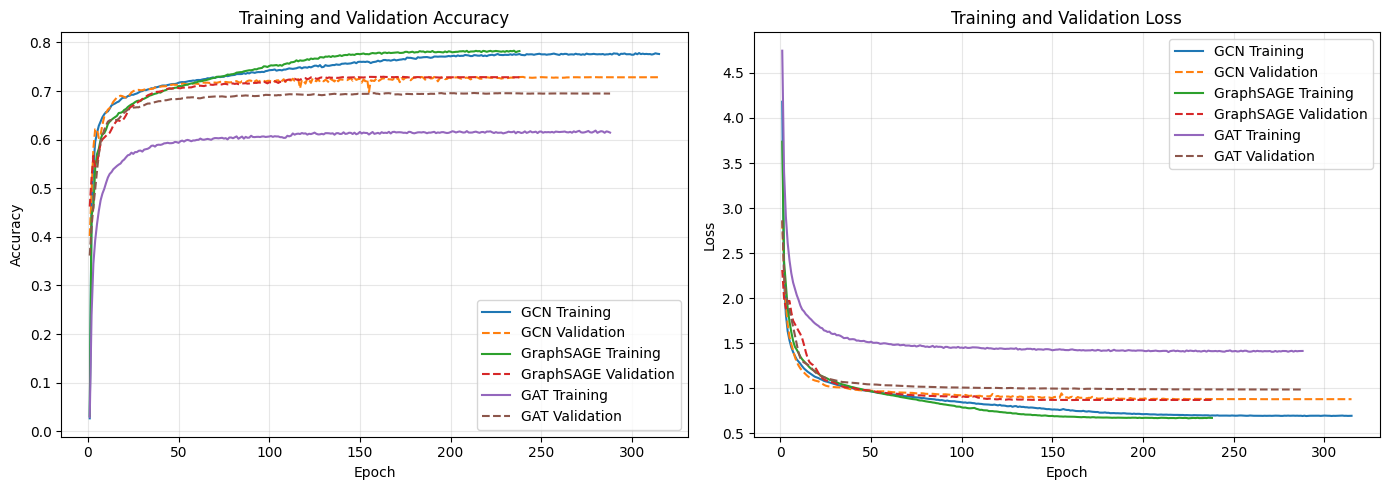

In [45]:
model_logs = {
    "GCN": gcn_training_log,
    "GraphSAGE": sage_training_log,
    "GAT": gat_training_log
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, log in model_logs.items():
    axes[0].plot(log["epoch"], log["train_accuracy"], label=f"{model_name} Training")
    axes[0].plot(log["epoch"], log["validation_accuracy"], linestyle="--", label=f"{model_name} Validation")
    axes[1].plot(log["epoch"], log["train_loss"], label=f"{model_name} Training")
    axes[1].plot(log["epoch"], log["validation_loss"], linestyle="--", label=f"{model_name} Validation")

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Training and Validation Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Training and Validation Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("reports/training_performance.png", dpi=300)
plt.show()


## **Save Trained Models & Training Results**

In [46]:
torch.save(gcn_model.state_dict(), "models_checkpoints/gcn_final.pt")
torch.save(sage_model.state_dict(), "models_checkpoints/graphsage_final.pt")
torch.save(gat_model.state_dict(), "models_checkpoints/gat_final.pt")

gcn_training_log.to_csv("reports/gcn_training_log.csv", index=False)
sage_training_log.to_csv("reports/graphsage_training_log.csv", index=False)
gat_training_log.to_csv("reports/gat_training_log.csv", index=False)

gcn_tuning_results.to_csv("reports/gcn_optimization_results.csv", index=False)
sage_tuning_results.to_csv("reports/graphsage_optimization_results.csv", index=False)
gat_tuning_results.to_csv("reports/gat_optimization_results.csv", index=False)

final_model_config = {
    "models": {
      "gcn": {
        "class": "GCN",
        "in_channels": gcn_config["in_channels"],
        "hidden_channels": best_gcn_config["hidden_channels"],
        "out_channels": gcn_config["out_channels"],
        "dropout": best_gcn_config["dropout"]
      },
      "graphsage": {
        "class": "GraphSAGE",
        "in_channels": sage_config["in_channels"],
        "hidden_channels": best_sage_config["hidden_channels"],
        "out_channels": sage_config["out_channels"],
        "dropout": best_sage_config["dropout"]
      },
      "gat": {
        "class": "GAT",
        "in_channels": gat_config["in_channels"],
        "hidden_channels": best_gat_config["hidden_channels"],
        "out_channels": gat_config["out_channels"],
        "dropout": best_gat_config["dropout"],
        "heads": best_gat_config["heads"]
      }
    },
    "optimization": {
      "gcn": {
        "learning_rate": best_gcn_config["learning_rate"],
        "weight_decay": best_gcn_config["weight_decay"]
      },
      "graphsage": {
        "learning_rate": best_sage_config["learning_rate"],
        "weight_decay": best_sage_config["weight_decay"]
      },
      "gat": {
        "learning_rate": best_gat_config["learning_rate"],
        "weight_decay": best_gat_config["weight_decay"]
      }
    },
    "seed": SEED
}

with open("models_checkpoints/trained_model_config.json", "w") as file:
    json.dump(final_model_config, file, indent=2)

print("Three model checkpoints, configurations, and Task 5 results saved successfully.")

Three model checkpoints, configurations, and Task 5 results saved successfully.


## **Task 5 Summary**

- GCN and GraphSAGE, the two required models, and GAT, the bonus advanced model, are trained using cross-entropy loss and Adam.
- Three configurations are compared independently for every architecture.
- GAT additionally tunes the number of attention heads with memory-aware hidden dimensions.
- Batch Normalization stabilizes all three Task 4 architectures.
- Bidirectional citation edges support information aggregation in both directions.
- A validation-loss scheduler, early stopping, and best-weight restoration improve convergence and limit overfitting.
- The executed logs, optimization tables, checkpoints, and final configuration file provide reproducible Task 5 deliverables.

# **TASK 06 - MODEL EVALUATION**

The two required models, GCN and GraphSAGE, and the bonus GAT model are evaluated on the validation and test sets using accuracy, macro precision, macro recall, and macro F1-score.

## **Evaluation Metrics**

In [47]:
@torch.no_grad()
def evaluate_model(model, split_idx):
    model.eval()

    logits = model(graph_data.x, graph_data.edge_index)
    predictions = logits[split_idx].argmax(dim=1).cpu().numpy()
    true_labels = graph_data.y[split_idx].cpu().numpy()

    return {
        "Accuracy": accuracy_score(true_labels, predictions),
        "Precision": precision_score(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        ),
        "Recall": recall_score(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        ),
        "F1 Score": f1_score(
            true_labels,
            predictions,
            average="macro",
            zero_division=0
        )
    }


print("Evaluation function created successfully.")

Evaluation function created successfully.


## **Validation & Test Set Results**

In [48]:
evaluation_results = []

for model_name, model in [
    ("GCN", gcn_model),
    ("GraphSAGE", sage_model),
    ("GAT", gat_model)
]:
    for split_name, split_idx in [
        ("Validation", valid_idx),
        ("Test", test_idx)
    ]:
        metrics = evaluate_model(model, split_idx)
        evaluation_results.append({
            "Model": model_name,
            "Dataset": split_name,
            **metrics
        })

evaluation_results = pd.DataFrame(evaluation_results)
metric_columns = ["Accuracy", "Precision", "Recall", "F1 Score"]
evaluation_results[metric_columns] = evaluation_results[metric_columns].round(4)
evaluation_results


,Model,Dataset,Accuracy,Precision,Recall,F1 Score
0,GCN,Validation,0.7291,0.5981,0.5215,0.5445
1,GCN,Test,0.7150,0.5728,0.4962,0.5154
2,GraphSAGE,Validation,0.7295,0.6170,0.5244,0.5431
3,GraphSAGE,Test,0.7136,0.5709,0.5012,0.5122
4,GAT,Validation,0.6960,0.5517,0.4469,0.4655
5,GAT,Test,0.6872,0.5728,0.4376,0.4532


## **Model Performance Comparison**

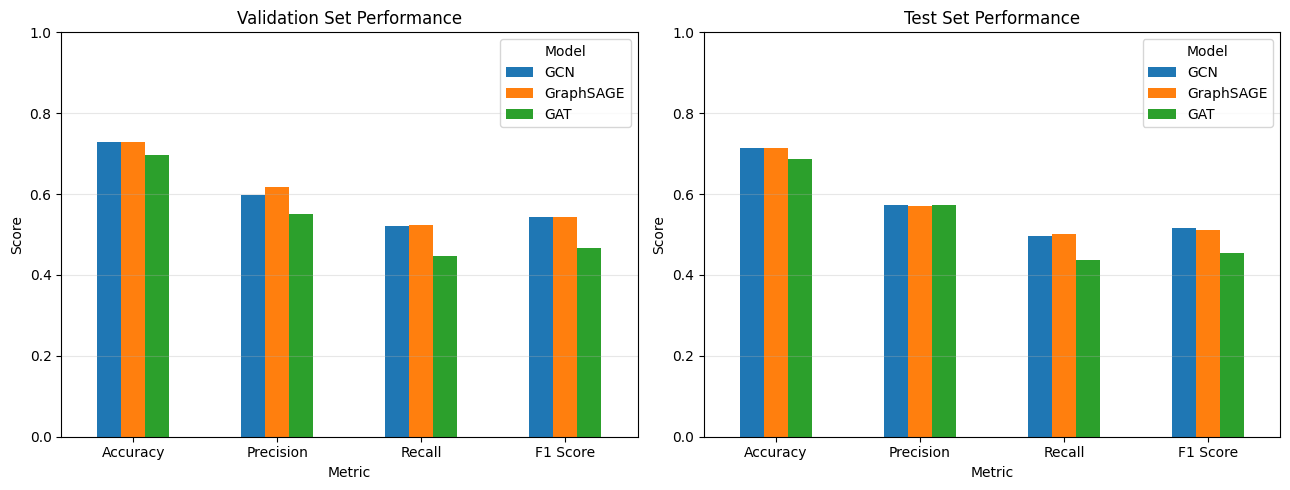

In [49]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for axis, dataset_name in zip(axes, ["Validation", "Test"]):
    subset = evaluation_results[
        evaluation_results["Dataset"] == dataset_name
    ].set_index("Model")

    subset[metrics].T.plot(kind="bar", ax=axis)
    axis.set_title(f"{dataset_name} Set Performance")
    axis.set_xlabel("Metric")
    axis.set_ylabel("Score")
    axis.set_ylim(0, 1.0)
    axis.tick_params(axis="x", rotation=0)
    axis.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("reports/model_evaluation_comparison.png", dpi=300)
plt.show()


## **Strengths, Weaknesses & Model Comparison**

In [50]:
def get_result(model_name, dataset_name):
    return evaluation_results[
        (evaluation_results["Model"] == model_name) &
        (evaluation_results["Dataset"] == dataset_name)
    ].iloc[0]

gcn_val = get_result("GCN", "Validation")
gcn_test = get_result("GCN", "Test")

print(
    f"GCN achieved {gcn_val['Accuracy']:.2%} validation accuracy and "
    f"{gcn_test['Accuracy']:.2%} test accuracy. Its main strength is "
    f"stable full-graph aggregation with Batch Normalization. On the test "
    f"set, macro precision was {gcn_test['Precision']:.2%}, macro recall was "
    f"{gcn_test['Recall']:.2%}, and macro F1-score was "
    f"{gcn_test['F1 Score']:.2%}. A validation-to-test accuracy reduction of "
    f"{(gcn_val['Accuracy'] - gcn_test['Accuracy']):.2%} indicates its "
    f"remaining generalization weakness."
)


GCN achieved 72.91% validation accuracy and 71.50% test accuracy. Its main strength is stable full-graph aggregation with Batch Normalization. On the test set, macro precision was 57.28%, macro recall was 49.62%, and macro F1-score was 51.54%. A validation-to-test accuracy reduction of 1.41% indicates its remaining generalization weakness.


In [51]:
sage_val = get_result("GraphSAGE", "Validation")
sage_test = get_result("GraphSAGE", "Test")

print(
    f"GraphSAGE achieved {sage_val['Accuracy']:.2%} validation accuracy and "
    f"{sage_test['Accuracy']:.2%} test accuracy. Its learned neighbourhood "
    f"aggregation is a strength for capturing citation-network patterns. On "
    f"the test set, macro precision was {sage_test['Precision']:.2%}, macro "
    f"recall was {sage_test['Recall']:.2%}, and macro F1-score was "
    f"{sage_test['F1 Score']:.2%}. A validation-to-test accuracy reduction of "
    f"{(sage_val['Accuracy'] - sage_test['Accuracy']):.2%} represents its "
    f"remaining generalization weakness."
)


GraphSAGE achieved 72.95% validation accuracy and 71.36% test accuracy. Its learned neighbourhood aggregation is a strength for capturing citation-network patterns. On the test set, macro precision was 57.09%, macro recall was 50.12%, and macro F1-score was 51.22%. A validation-to-test accuracy reduction of 1.59% represents its remaining generalization weakness.


In [52]:
gat_val = get_result("GAT", "Validation")
gat_test = get_result("GAT", "Test")

print(
    f"GAT achieved {gat_val['Accuracy']:.2%} validation accuracy and "
    f"{gat_test['Accuracy']:.2%} test accuracy. Its learned attention weights "
    f"can emphasize more informative citation neighbours and support "
    f"attention-based explainability. On the test set, macro precision was "
    f"{gat_test['Precision']:.2%}, macro recall was {gat_test['Recall']:.2%}, "
    f"and macro F1-score was {gat_test['F1 Score']:.2%}. Its main weakness is "
    f"the additional memory and computation required by multi-head attention."
)


GAT achieved 69.60% validation accuracy and 68.72% test accuracy. Its learned attention weights can emphasize more informative citation neighbours and support attention-based explainability. On the test set, macro precision was 57.28%, macro recall was 43.76%, and macro F1-score was 45.32%. Its main weakness is the additional memory and computation required by multi-head attention.


In [53]:
test_results = evaluation_results[
    evaluation_results["Dataset"] == "Test"
].set_index("Model")

best_accuracy_model = test_results["Accuracy"].idxmax()
best_f1_model = test_results["F1 Score"].idxmax()

print(
    f"{best_accuracy_model} achieved the highest test accuracy "
    f"({test_results.loc[best_accuracy_model, 'Accuracy']:.2%}). "
    f"{best_f1_model} achieved the highest macro F1-score "
    f"({test_results.loc[best_f1_model, 'F1 Score']:.2%}). "
    f"GCN provides stable normalized aggregation, GraphSAGE uses learned "
    f"neighbour aggregation, and GAT learns per-edge attention weights but "
    f"has greater memory and computational cost. The final selection should "
    f"consider accuracy, macro F1, and efficiency together."
)


GCN achieved the highest test accuracy (71.50%). GCN achieved the highest macro F1-score (51.54%). GCN provides stable normalized aggregation, GraphSAGE uses learned neighbour aggregation, and GAT learns per-edge attention weights but has greater memory and computational cost. The final selection should consider accuracy, macro F1, and efficiency together.


## **Save Evaluation Results**

In [54]:
evaluation_results.to_csv(
    "reports/model_evaluation_results.csv",
    index=False
)

print("Task 6 evaluation results saved successfully.")

Task 6 evaluation results saved successfully.


In [55]:
validation_results = evaluation_results[
    evaluation_results["Dataset"] == "Validation"
].set_index("Model")
test_results = evaluation_results[
    evaluation_results["Dataset"] == "Test"
].set_index("Model")

summary = pd.DataFrame({
    "Best Validation Accuracy": validation_results["Accuracy"],
    "Test Accuracy": test_results["Accuracy"],
    "Test Macro Precision": test_results["Precision"],
    "Test Macro Recall": test_results["Recall"],
    "Test Macro F1": test_results["F1 Score"]
}).round(4)

print("Task 6 summary:")
display(summary)
print("Best model by test accuracy:", test_results["Accuracy"].idxmax())
print("Best model by test macro F1:", test_results["F1 Score"].idxmax())


Task 6 summary:


,Best Validation Accuracy,Test Accuracy,Test Macro Precision,Test Macro Recall,Test Macro F1
Model,,,,,
GCN,0.7291,0.7150,0.5728,0.4962,0.5154
GraphSAGE,0.7295,0.7136,0.5709,0.5012,0.5122
GAT,0.6960,0.6872,0.5728,0.4376,0.4532


Best model by test accuracy: GCN
Best model by test macro F1: GCN
